In [72]:
#install pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("/Users/zeldudu/Documents/Mukbang Analysis/data/mukbang_bulk_metadata.csv")

# Look at the basic structure
print(len(df))
df.describe()

270


,duration,view_count,average_rating,age_limit,release_timestamp,comment_count,like_count,channel_follower_count,upload_date,timestamp,...,quality,tbr,filesize_approx,width,language_preference,preference,vbr,abr,aspect_ratio,release_date
count,270.000000,2.700000e+02,0.0,270.0,3.000000e+00,266.000000,2.630000e+02,2.700000e+02,2.700000e+02,2.700000e+02,...,270.000000,270.000000,2.700000e+02,270.000000,270.0,0.0,0.0,0.0,270.000000,3.000000e+00
mean,734.329630,8.681537e+06,NaN,0.0,1.736632e+09,2836.751880,2.224442e+05,5.774752e+06,2.023946e+07,1.714706e+09,...,5.985185,496.272781,3.877517e+07,490.118519,-1.0,NaN,NaN,NaN,1.139778,2.024716e+07
std,1043.552472,2.615736e+07,NaN,0.0,1.115600e+07,10357.296761,5.367689e+05,2.553342e+07,1.409156e+04,4.357378e+07,...,0.171812,131.090395,5.692862e+07,144.829861,0.0,NaN,NaN,NaN,0.609189,5.491756e+03
min,6.000000,1.110000e+02,NaN,0.0,1.723750e+09,2.000000,5.000000e+00,7.000000e+00,2.018013e+07,1.517231e+09,...,5.000000,209.481000,4.124780e+05,202.000000,-1.0,NaN,NaN,NaN,0.560000,2.024082e+07
25%,46.000000,2.377608e+05,NaN,0.0,1.733365e+09,151.250000,6.762500e+03,3.080000e+05,2.023122e+07,1.702764e+09,...,6.000000,379.561000,3.136149e+06,360.000000,-1.0,NaN,NaN,NaN,0.560000,2.024557e+07
50%,192.500000,1.404964e+06,NaN,0.0,1.742980e+09,602.500000,3.531800e+04,1.200000e+06,2.024110e+07,1.730643e+09,...,6.000000,537.068000,9.617847e+06,360.000000,-1.0,NaN,NaN,NaN,0.560000,2.025033e+07
75%,1048.000000,5.419729e+06,NaN,0.0,1.743072e+09,1600.000000,2.112775e+05,4.320000e+06,2.025033e+07,1.743389e+09,...,6.000000,597.872750,5.388461e+07,640.000000,-1.0,NaN,NaN,NaN,1.780000,2.025033e+07
max,9343.000000,3.030976e+08,NaN,0.0,1.743165e+09,135000.000000,4.747760e+06,4.060000e+08,2.025062e+07,1.750370e+09,...,7.000000,736.786000,4.431462e+08,640.000000,-1.0,NaN,NaN,NaN,1.780000,2.025033e+07


In [73]:
# Check column names
df.columns.tolist()

# Check for nulls
df.isnull().sum()

# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 96 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      270 non-null    object 
 1   title                   270 non-null    object 
 2   formats                 270 non-null    object 
 3   thumbnails              270 non-null    object 
 4   thumbnail               270 non-null    object 
 5   description             176 non-null    object 
 6   channel_id              270 non-null    object 
 7   channel_url             270 non-null    object 
 8   duration                270 non-null    int64  
 9   view_count              270 non-null    int64  
 10  average_rating          0 non-null      float64
 11  age_limit               270 non-null    int64  
 12  webpage_url             270 non-null    object 
 13  categories              270 non-null    object 
 14  tags                    270 non-null    ob

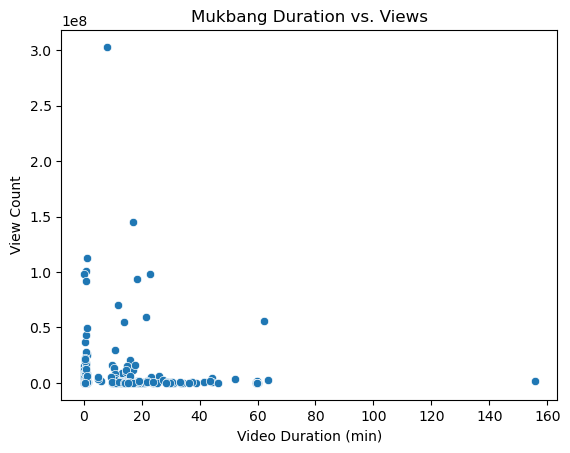

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert duration to minutes (if it's in seconds)
df['duration_min'] = df['duration'] / 60

# Plot duration vs. views
sns.scatterplot(data=df, x='duration_min', y='view_count')
plt.xlabel("Video Duration (min)")
plt.ylabel("View Count")
plt.title("Mukbang Duration vs. Views")
plt.show()

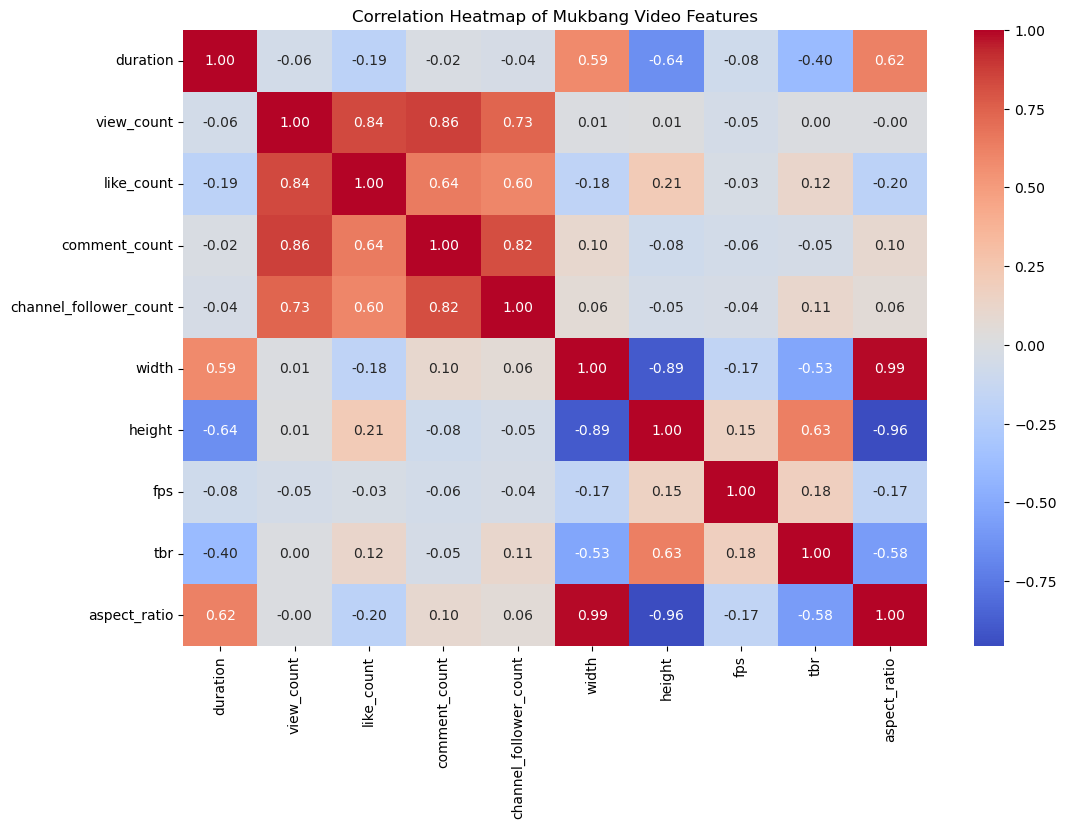

In [75]:
relevant_cols = [
    'duration',                  # video length (sec)
    'view_count',                # total views
    'like_count',                # total likes
    'comment_count',            # comments
    'channel_follower_count',    # audience size
    'width', 'height',           # video resolution
    'fps', 'tbr',                # frame rate, total bit rate
    'aspect_ratio'               # format
]

# Subset to relevant columns
heatmap_df = df[relevant_cols]

# Drop columns with all NaNs
heatmap_df = heatmap_df.dropna(axis=1, how='all')

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Mukbang Video Features")
plt.show()

In [76]:
# Posting time

# upload_date is in YYYYMMDD format
df['upload_date'] = pd.to_datetime(df['upload_date'], format='%Y%m%d')
df['upload_dayofweek'] = df['upload_date'].dt.day_name()
df['upload_hour'] = pd.to_datetime(df['timestamp'], unit='s').dt.hour

In [77]:
df['is_asmr'] = df['title'].str.contains("ASMR", case=False) | df['description'].str.contains("ASMR", case=False)

In [79]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

labels = ["ASMR", "talking", "Korean food", "Italian food", "Seafood", "Japanese food", "Fastfood", "Dessert", "Noodles", "Indian food"]

df['category'] = df['title'].apply(lambda x: classifier(x, labels)['labels'][0])

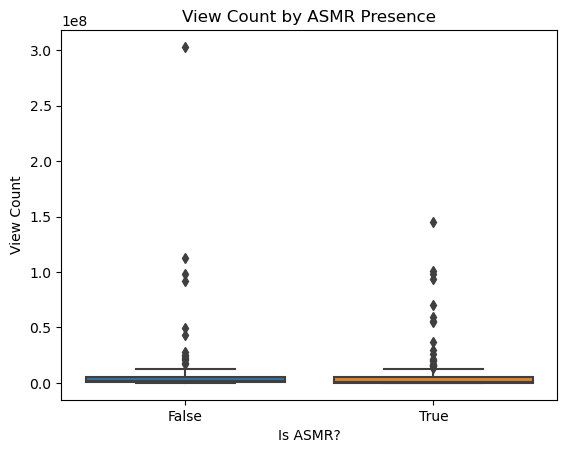

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='is_asmr', y='view_count', data=df)
plt.title('View Count by ASMR Presence')
plt.xlabel('Is ASMR?')
plt.ylabel('View Count')
plt.show()

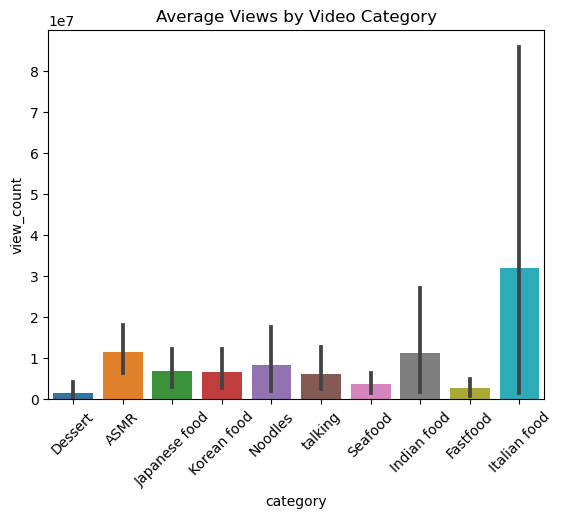

In [81]:
sns.barplot(x='category', y='view_count', data=df)
plt.title('Average Views by Video Category')
plt.xticks(rotation=45)
plt.show()


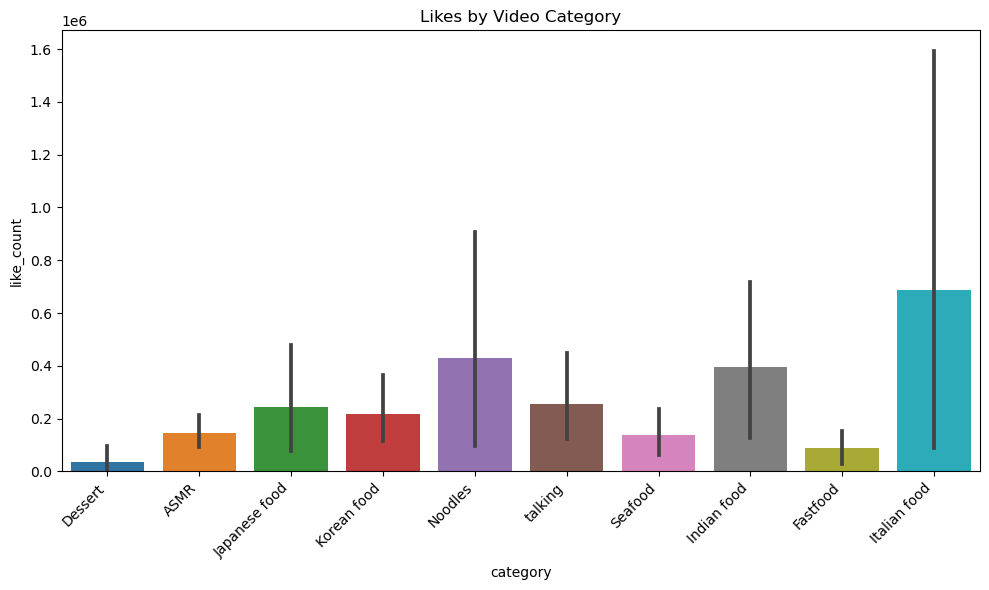

In [82]:
# Create bar plot of likes by category
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='category', y='like_count')
plt.xticks(rotation=45, ha='right')
plt.title("Likes by Video Category")
plt.tight_layout() # Prevent label cutoff
plt.show()

Text(0.5, 1.0, 'Views by Day of Upload')

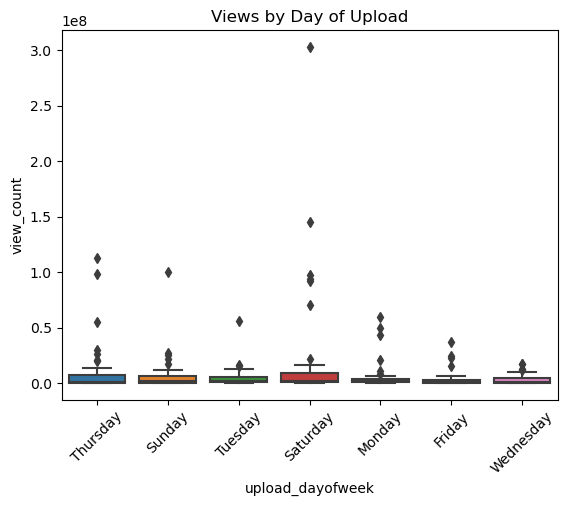

In [83]:
# Day of week vs. views
sns.boxplot(x='upload_dayofweek', y='view_count', data=df)
plt.xticks(rotation=45)
plt.title("Views by Day of Upload")


Text(0.5, 1.0, 'Views by Hour of Upload')

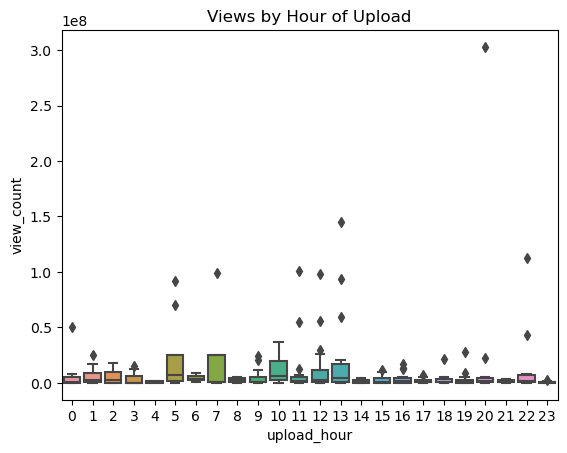

In [84]:
# Hour of upload vs. views
sns.boxplot(x='upload_hour', y='view_count', data=df)
plt.title("Views by Hour of Upload")


Text(0.5, 1.0, 'Like Efficiency by ASMR')

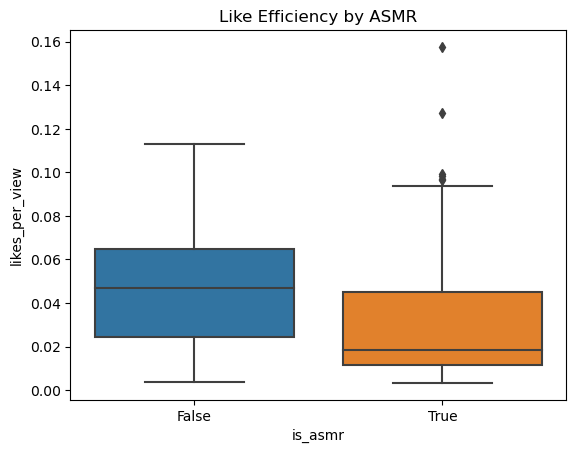

In [85]:
df['likes_per_view'] = df['like_count'] / df['view_count']
df['comments_per_view'] = df['comment_count'] / df['view_count']

sns.boxplot(x='is_asmr', y='likes_per_view', data=df)
plt.title("Like Efficiency by ASMR")


In [86]:
df.groupby('channel')['view_count'].mean().sort_values(ascending=False).head(10)

channel
MrBeast              303097586.0
설기양SULGI             145370388.0
Jayllnn              112968286.0
HUBA후바               100603511.0
GOYUMYUM고얌얌           98594636.0
Saapattu Raman        97813263.0
suellASMR             59510094.0
당비 Dangbee EATING     55846086.0
Bokyoung              54689917.0
Bayashi TV            52153627.5
Name: view_count, dtype: float64

In [87]:
df['views_per_sub'] = df['view_count'] / df['channel_follower_count']
df['likes_per_sub'] = df['like_count'] / df['channel_follower_count']
df['comments_per_sub'] = df['comment_count'] / df['channel_follower_count']

Text(0.5, 1.0, 'Views per Follower vs Channel Size')

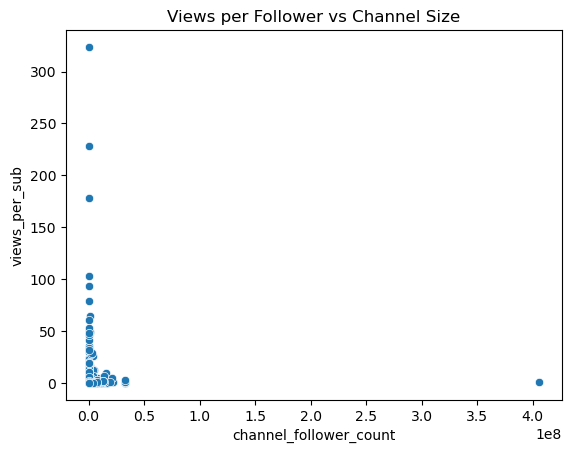

In [88]:
sns.scatterplot(x='channel_follower_count', y='views_per_sub', data=df)
plt.title("Views per Follower vs Channel Size")

Text(0.5, 1.0, 'Views vs. Channel Size')

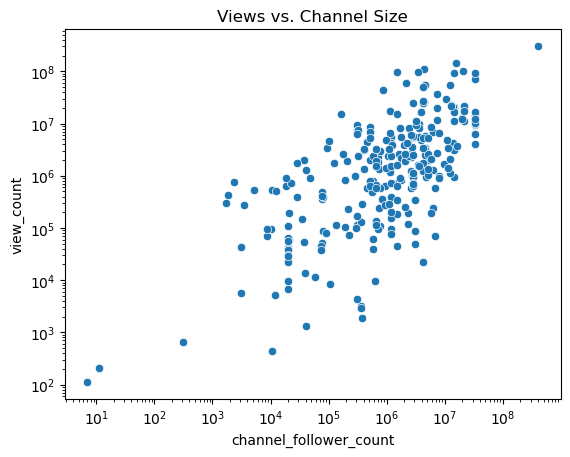

In [89]:
sns.scatterplot(x='channel_follower_count', y='view_count', data=df)
plt.xscale("log")
plt.yscale("log")
plt.title("Views vs. Channel Size")


Text(0.5, 1.0, 'Engagement Score by ASMR Format')

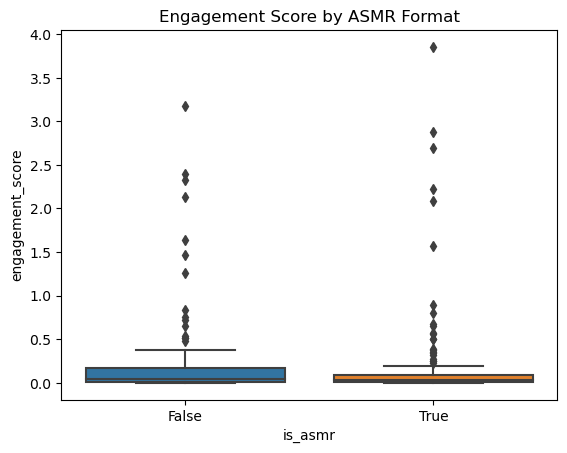

In [90]:
df['engagement_score'] = (
    df['like_count'] + df['comment_count']
) / df['channel_follower_count']

sns.boxplot(x='is_asmr', y='engagement_score', data=df)
plt.title("Engagement Score by ASMR Format")


In [91]:
top_performers = df.sort_values(by='views_per_sub', ascending=False).head(5)
top_performers[['title', 'channel', 'view_count', 'channel_follower_count', 'views_per_sub']]


,title,channel,view_count,channel_follower_count,views_per_sub
61,"TIKTOK MUKBANG COMPILATION P2-BULDAK RAMEN, CH...",khadakyt,754838,2330,323.964807
63,Some of the best samyang buldak ramen tiktok m...,Teamuks˚୨୧⋆,420811,1840,228.701630
191,TIKTOKS BEST WINGSTOP MUKBANG VIDEOS PART 21 |...,Tiktok,299351,1680,178.185119
236,Let’s eat World’s Strongest Matcha Chocolate💚,Sera’s Asian Eats,535031,5200,102.890577
13,ASMR DUBAI CHOCOLATE MUKBANG 🍫 @Sriparnaa__a,FOOD MUKBANG ASMR,14955660,160000,93.472875


Text(0.5, 1.0, 'Channel Size by Content Type')

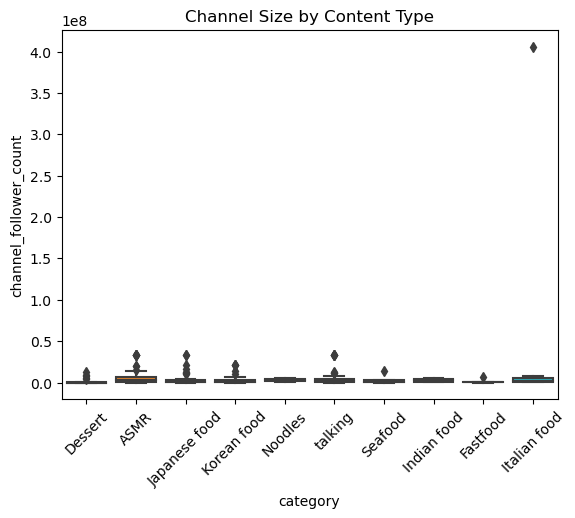

In [92]:
sns.boxplot(x='category', y='channel_follower_count', data=df)
plt.xticks(rotation=45)
plt.title("Channel Size by Content Type")